In [1]:
import numpy as np
import pandas as pd
from scipy.io import mmread

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (6, 4)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import anndata as ad
import scanpy as sc
import maxfuse as mf

import seaborn as sns


/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packag

In [2]:
# read in protein data - see rna/pro umap r script to trace
protein = pd.read_csv("../data/pro_maxinput.csv") 
protein.head()

/var/folders/3_/pf5ff_p57fqfsm6w00s_hg480000gn/T/ipykernel_67909/4168464743.py:2: DtypeWarning: Columns (92,95,96,98,99,100,101,106,108,109,114,115,130,131,132,133,134,135,136,140,141,143,144,146,147,148,150,151,152,154,155,157,158,163,164,165,166,167,168,169,170) have mixed types. Specify dtype option on import or set low_memory=False.
  protein = pd.read_csv("../data/pro_maxinput.csv")


,tma_fov,Unnamed..0,cellLabel,X_cent,Y_cent,cellSize,cellWidth,cellHeight,M_CD3,M_CD45,...,TMA.y,FOV_RNA,FOV_Pro,ann,global_x,global_y,CarcVsSarc,VIM,VISTA,BH_ann
0,4_10,92833,1259,2354,1188,1856,56,52,75.09265,52.20448,...,4,10,9,D8 Chondrosarcoma,202354,201188,Spindle carcinoma vs sarcoma,17621.173973,1237.838536,Tumor
1,4_10,92834,1260,1293,1189,3128,84,76,326.27470,49.71248,...,4,10,9,D8 Chondrosarcoma,201293,201189,Spindle carcinoma vs sarcoma,24154.380605,4615.930564,Tumor
2,4_10,92832,1258,1750,1187,4528,94,76,120.79180,62.61134,...,4,10,9,D8 Chondrosarcoma,201750,201187,Spindle carcinoma vs sarcoma,14614.010635,1132.174257,Tumor
3,4_10,92814,1237,2093,1162,2688,76,52,74.20967,48.98110,...,4,10,9,D8 Chondrosarcoma,202093,201162,Myometrium,20470.093551,617.469808,Tumor
4,4_10,92837,1263,3391,1189,4360,86,72,118.87700,52.32948,...,4,10,9,D8 Chondrosarcoma,203391,201189,Endothelial,36151.385205,1675.974282,Tumor


In [3]:
# # input csv contains meta info, take only protein features
protein_features = ["X4.1BB",       "B7.H3",        "BCL2",         "Beta.catenin", "CCR7",        
"CD3",          "CD4",          "CD8",          "CD11b",        "CD11c",       
"CD14",         "CD15",         "CD16",         "CD19",         "CD20",        
"CD27",         "CD31",         "CD34",         "CD38",         "CD39",        
"CD40",         "CD45",         "CD45RA",       "CD56",         "CD68",        
"CD123",        "CD127",        "CD138",        "CD163",        "CTLA4",       
"EGFR",         "EpCAM",        "FABP4",        "FN1",          "FOXP3",       
"GITR",         "GZMA",         "GZMB",         "HER2",         "HLA.DRA",     
"ICAM1",        "ICOS",         "IDO1",         "IgD",          "IL.1B",       
"IL.18",        "iNOS",         "KI67",         "LAG3",         "LAMP1",       
"MsIgG1",       "NF.kBp65",     "p53",          "panRAS",       "PD1",         
"PDL1",         "PDL2",         "RbIgG",        "SMA",          "STING",       
"TCF.1",        "TIM3",         "VIM",          "VISTA"       ]
# # convert to AnnData
protein_adata = ad.AnnData(
    protein[protein_features].to_numpy(), dtype=np.float32
)
protein_adata.var_names = protein[protein_features].columns
protein_adata.to_df().head()

,X4.1BB,B7.H3,BCL2,Beta.catenin,CCR7,CD3,CD4,CD8,CD11b,CD11c,...,PD1,PDL1,PDL2,RbIgG,SMA,STING,TCF.1,TIM3,VIM,VISTA
0,185.623901,357.019196,1415.735962,921.563782,232.658203,135.948700,766.830627,470.342987,794.968811,29.518450,...,72.560753,208.525406,571.964783,246.870895,16113.469727,1985.120972,600.156128,1118.370972,17621.173828,1237.838501
1,372.152100,719.676697,688.426819,965.951782,90.845222,44.497082,2291.290039,309.891815,2591.527100,1234.301025,...,59.901249,161.339493,648.533508,151.531006,10240.629883,1689.192017,831.590881,1905.760010,24154.380859,4615.930664
2,210.099792,678.825806,1059.328979,817.202698,237.817795,103.994102,786.112427,572.523315,1036.296997,291.274902,...,85.597908,191.554703,479.917389,275.636688,20593.759766,1437.758057,1459.538940,1473.421997,14614.010742,1132.174316
3,171.435196,479.119598,484.491913,719.703308,137.041794,26.583620,722.096924,407.790192,757.921082,17.814520,...,51.544910,232.831100,461.061096,232.110397,25979.640625,1963.499023,602.070984,1470.230957,20470.093750,617.469788
4,267.365509,1477.171997,733.985107,1165.764038,226.163605,33.627460,1529.326050,383.189301,1290.683960,122.267899,...,102.424896,143.150803,647.044128,168.562805,31760.449219,1668.553955,541.432983,2286.980957,36151.386719,1675.974243


In [5]:
labels_codex = protein['phenoShort'].to_numpy()
np.unique(labels_codex)

array(['B', 'Benign stroma',
       'Benign stroma vs perivascular smooth muscle', 'CD4', 'CD8',
       'Carcinoma', 'DC', 'Endothelial',
       'Fibroblast desmoplastic stroma population',
       'HG sarcoma vs PD carcinoma', 'M1', 'M2', 'Myometrium',
       'Neutrophil', 'Other', 'Perivascular smooth muscle',
       'Rhabdomyosarcoma', 'Sarcoma', 'Spindle carcinoma vs sarcoma'],
      dtype=object)

In [23]:
# read in RNA data
rna = pd.read_csv("../data/rna_maxinput.csv") 
rna

,AATK,ABL1,ABL2,ACE,ACE2,ACKR1,ACKR3,ACKR4,ACTA2,ACTG2,...,WNT5B,WNT7A,WNT7B,WNT9A,XBP1,XCL1,XCL2,YBX3,YES1,ZFP36
0,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,7.751938,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
212869,0.0,0.0,0.0,0.0,0.0,0.0,29.41176,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0
212870,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,27.02703,0.0,0.000000,0.0,0.0
212871,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0
212872,0.0,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.000000,0.0,0.0


In [28]:
rna_adata = ad.AnnData(rna.to_numpy(), dtype=np.float32)
rna_adata.var_names = rna.columns
rna_adata

AnnData object with n_obs × n_vars = 212874 × 979

In [29]:
# read in celltyle labels
metadata_rna = pd.read_csv('../data/rna_maxinput_meta.csv')
labels_rna   = metadata_rna['annV7_noNum'].to_numpy()

/var/folders/3_/pf5ff_p57fqfsm6w00s_hg480000gn/T/ipykernel_67909/3931542969.py:2: DtypeWarning: Columns (32,35,36,39,40,41,44,46,48,54,70,71,72,73,74,75,76,79,80,83,84,86,87,88,90,91,92,94,95,97,98,104,105,106,107,108,109,110,111) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_rna = pd.read_csv('../data/rna_maxinput_meta.csv')


In [30]:
correspondence = pd.read_csv('../data/protein_gene_conversion.csv')
correspondence.head()

,Protein name,RNA name
0,CD80,CD80
1,CD86,CD86
2,CD274,CD274
3,CD273,PDCD1LG2
4,CD275,ICOSLG


In [31]:
rna_protein_correspondence = []

for i in range(correspondence.shape[0]):
    curr_protein_name, curr_rna_names = correspondence.iloc[i]
    if curr_protein_name not in protein_adata.var_names:
        continue
    if curr_rna_names.find('Ignore') != -1: # some correspondence ignored eg. protein isoform to one gene
        continue
    curr_rna_names = curr_rna_names.split('/') # eg. one protein to multiple genes
    for r in curr_rna_names:
        if r in rna_adata.var_names:
            rna_protein_correspondence.append([r, curr_protein_name])
            
rna_protein_correspondence = np.array(rna_protein_correspondence)

In [32]:
print(rna_protein_correspondence)
print(len(rna_protein_correspondence))

[['ITGAM' 'CD11b']
 ['CD40' 'CD40']
 ['CD3E' 'CD3']
 ['CD3D' 'CD3']
 ['CD3G' 'CD3']
 ['CD4' 'CD4']
 ['CD8A' 'CD8']
 ['CD8B' 'CD8']
 ['PTPRC' 'CD45']
 ['PTPRCAP' 'CD45']
 ['CD19' 'CD19']
 ['ITGAX' 'CD11c']
 ['CD34' 'CD34']
 ['PTPRC' 'CD45RA']
 ['PTPRCAP' 'CD45RA']
 ['IL3RA' 'CD123']
 ['CD14' 'CD14']
 ['MS4A1' 'CD20']
 ['PECAM1' 'CD31']
 ['CD27' 'CD27']
 ['ENTPD1' 'CD39']
 ['CD68' 'CD68']
 ['CD163' 'CD163']
 ['CD38' 'CD38']
 ['IL7R' 'CD127']
 ['FCGR3A' 'CD16']
 ['FOXP3' 'FOXP3']
 ['HAVCR2' 'TIM3']
 ['CD274' 'PDL1']
 ['CTLA4' 'CTLA4']
 ['CCR7' 'CCR7']
 ['PDCD1' 'PD1']
 ['BCL2' 'BCL2']
 ['IGHD' 'IgD']
 ['EGFR' 'EGFR']
 ['VSIR' 'VISTA']
 ['ICOS' 'ICOS']
 ['EPCAM' 'EpCAM']
 ['FABP4' 'FABP4']]
39


In [39]:
## check what is not in
## update later
found = [rna_protein_correspondence[x][1] for x in range(len(rna_protein_correspondence))]
[x for x in protein_adata.var_names if x not in found]

['X4.1BB',
 'B7.H3',
 'Beta.catenin',
 'CD15',
 'CD56',
 'CD138',
 'FN1',
 'GITR',
 'GZMA',
 'GZMB',
 'HER2',
 'HLA.DRA',
 'ICAM1',
 'IDO1',
 'IL.1B',
 'IL.18',
 'iNOS',
 'KI67',
 'LAG3',
 'LAMP1',
 'MsIgG1',
 'NF.kBp65',
 'p53',
 'panRAS',
 'PDL2',
 'RbIgG',
 'SMA',
 'STING',
 'TCF.1',
 'VIM']

In [41]:
# Columns rna_shared and protein_shared are matched.
# One may encounter "Variable names are not unique" warning,
# this is fine and is because one RNA may encode multiple proteins and vice versa.
rna_shared = rna_adata[:, rna_protein_correspondence[:, 0]]
protein_shared = protein_adata[:, rna_protein_correspondence[:, 1]]

In [42]:
# Make sure no column is static
mask = (
    (rna_shared.X.std(axis=0) > 0.2) 
    & (protein_shared.X.std(axis=0) > 0.00001)
)
rna_shared = rna_shared[:, mask]
protein_shared = protein_shared[:, mask]
print([rna_shared.shape,protein_shared.shape])

[(212874, 39), (132403, 39)]


array([[<Axes: title={'center': '0'}>]], dtype=object)

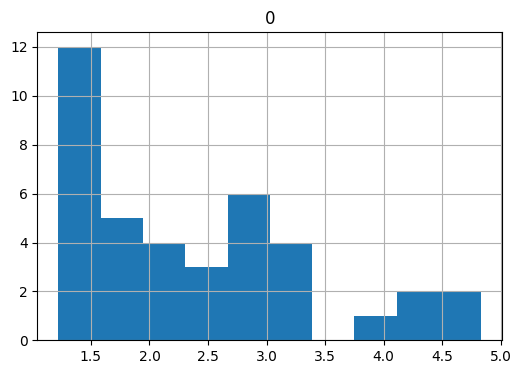

In [43]:
pd.DataFrame(rna_shared.X.std(axis=0)).hist()

array([[<Axes: title={'center': '0'}>]], dtype=object)

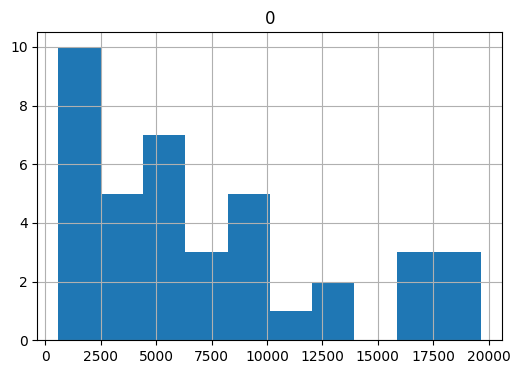

In [44]:
pd.DataFrame(protein_shared.X.std(axis=0)).hist()

In [45]:
## Bokai comment here: due to input normed, skip but only scale

sc.pp.scale(rna_shared)

/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:842: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [47]:

# process protein_shared
#sc.pp.normalize_total(protein_shared)
#sc.pp.log1p(protein_shared)
sc.pp.scale(protein_shared)

/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/scanpy/preprocessing/_simple.py:842: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [49]:
### Bokai: same here

# process all RNA features
#sc.pp.normalize_total(rna_adata)
#sc.pp.log1p(rna_adata)
#sc.pp.highly_variable_genes(rna_adata, n_top_genes=5000)
# only retain highly variable genes
#rna_adata = rna_adata[:, rna_adata.var.highly_variable].copy()
rna_adata = rna_adata
sc.pp.scale(rna_adata)

In [50]:
# Bokai: same here
# process all protein features
#sc.pp.normalize_total(protein_adata)
#sc.pp.log1p(protein_adata)
sc.pp.scale(protein_adata)

In [51]:
# make sure no feature is static
rna_active = rna_adata.X
protein_active = protein_adata.X
rna_active = rna_active[:, rna_active.std(axis=0) > 1e-5] # these are fine since already using variable features
protein_active = protein_active[:, protein_active.std(axis=0) > 1e-5] # protein are generally variable

In [52]:
rna_shared = rna_shared.X
protein_shared = protein_shared.X

In [53]:
# inspect shape of the four matrices
print(rna_active.shape)
print(protein_active.shape)
print(rna_shared.shape)
print(protein_shared.shape)

(212874, 979)
(132403, 64)
(212874, 39)
(132403, 39)


In [54]:
# call constructor for Fusor object
# which is the main object for running MaxFuse pipeline
fusor = mf.model.Fusor(
    shared_arr1=rna_shared,
    shared_arr2=protein_shared,
    active_arr1=rna_active,
    active_arr2=protein_active,
    labels1=None,
    labels2=None
)

In [56]:
fusor.split_into_batches(
    max_outward_size=8000,
    matching_ratio=5,
    metacell_size=2,
    verbose=True
)

The first data is split into 12 batches, average batch size is 17739, and max batch size is 17745.
The second data is split into 3 batches, average batch size is 44134, and max batch size is 44135.
Batch to batch correspondence is:
  ['0<->0', '0<->1', '0<->2', '1<->0', '1<->1', '1<->2', '2<->0', '2<->1', '2<->2', '3<->0', '3<->1', '3<->2', '4<->0', '4<->1', '4<->2', '5<->0', '5<->1', '5<->2', '6<->0', '6<->1', '6<->2', '7<->0', '7<->1', '7<->2', '8<->0', '8<->1', '8<->2', '9<->0', '9<->1', '9<->2', '10<->0', '10<->1', '10<->2', '11<->0', '11<->1', '11<->2'].


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 11'}, xlabel='Index', ylabel='Singular value'>)

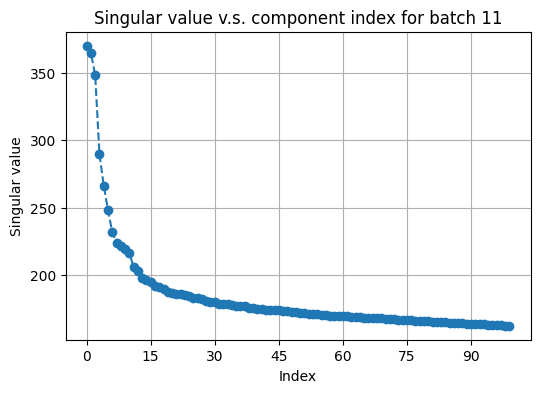

In [57]:
# plot top singular values of avtive_arr1 on a random batch
fusor.plot_singular_values(
    target='active_arr1',
    n_components=None # can also explicitly specify the number of components
)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 1'}, xlabel='Index', ylabel='Singular value'>)

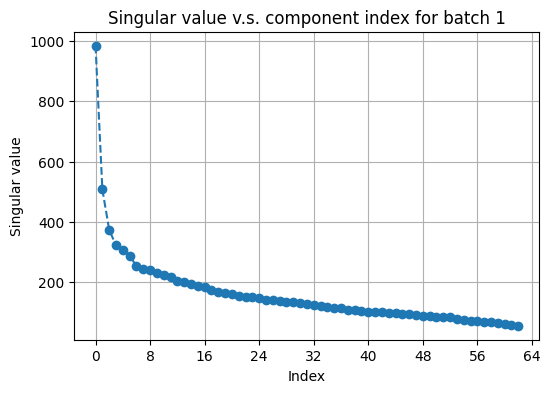

In [58]:
# plot top singular values of avtive_arr2 on a random batch
fusor.plot_singular_values(
    target='active_arr2',
    n_components=None
)

In [59]:
fusor.construct_graphs(
    n_neighbors1=15,
    n_neighbors2=15,
    svd_components1=45,
    svd_components2=32,
    resolution1=2,
    resolution2=2,
    # if two resolutions differ less than resolution_tol
    # then we do not distinguish between then
    resolution_tol=0.1,
    verbose=True
)

Aggregating cells in arr1 into metacells of average size 2...
Constructing neighborhood graphs for cells in arr1...
Now at batch 0...


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Now at batch 1...
Now at batch 2...
Now at batch 3...
Now at batch 4...
Now at batch 5...
Now at batch 6...
Now at batch 7...
Now at batch 8...
Now at batch 9...
Now at batch 10...
Now at batch 11...
Graph construction finished!
Clustering into metacells...
Now at batch 0...
Metacell clustering finished!
Now at batch 1...
Metacell clustering finished!
Now at batch 2...
Metacell clustering finished!
Now at batch 3...
Metacell clustering finished!
Now at batch 4...
Metacell clustering finished!
Now at batch 5...
Metacell clustering finished!
Now at batch 6...
Metacell clustering finished!
Now at batch 7...
Metacell clustering finished!
Now at batch 8...
Metacell clustering finished!
Now at batch 9...
Metacell clustering finished!
Now at batch 10...
Metacell clustering finished!
Now at batch 11...
Metacell clustering finished!
Constructing neighborhood graphs for cells in arr1...
Now at batch 0...
Now at batch 1...
Now at batch 2...
Now at batch 3...
Now at batch 4...
Now at batch 5...
No

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 8'}, xlabel='Index', ylabel='Singular value'>)

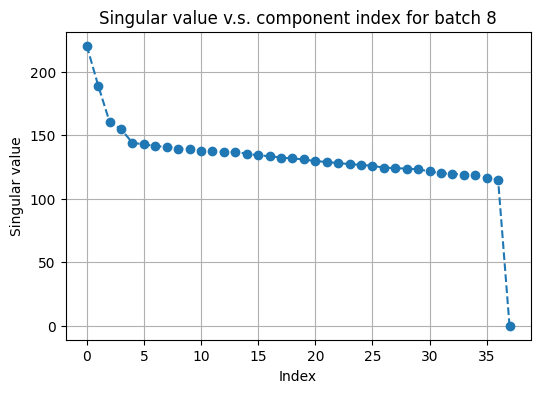

In [60]:
# plot top singular values of shared_arr1 on a random batch
fusor.plot_singular_values(
    target='shared_arr1',
    n_components=None,
)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Singular value v.s. component index for batch 0'}, xlabel='Index', ylabel='Singular value'>)

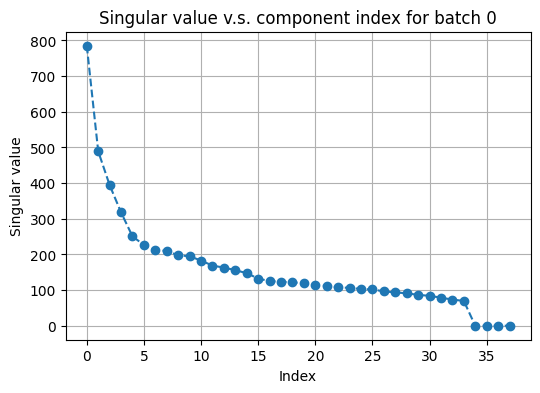

In [61]:
# plot top singular values of shared_arr2 on a random batch
fusor.plot_singular_values(
    target='shared_arr2',
 
    n_components=None
)

In [62]:
fusor.find_initial_pivots(
    wt1=0.5, wt2=0.5,
    svd_components1=25, svd_components2=25
)

Now at batch 0<->0...
Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 6<->0...
Now at batch 6<->1...
Now at batch 6<->2...
Now at batch 7<->0...
Now at batch 7<->1...
Now at batch 7<->2...
Now at batch 8<->0...
Now at batch 8<->1...
Now at batch 8<->2...
Now at batch 9<->0...
Now at batch 9<->1...
Now at batch 9<->2...
Now at batch 10<->0...
Now at batch 10<->1...
Now at batch 10<->2...
Now at batch 11<->0...
Now at batch 11<->1...
Now at batch 11<->2...
Done!


(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Canonical correlation v.s. component index for batch 11<->1'}, xlabel='Index', ylabel='Canonical correlation'>)

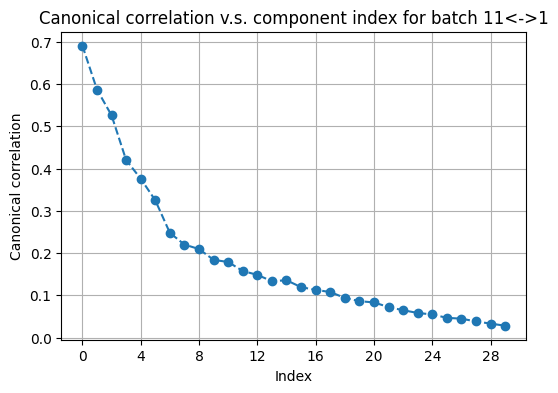

In [65]:
# plot top canonical correlations in a random batch
fusor.plot_canonical_correlations(
    svd_components1=45,
    svd_components2=32,
    cca_components=30
)

In [66]:
fusor.refine_pivots(
    wt1=0.5, wt2=0.5,
    svd_components1=30, svd_components2=30,
    cca_components=18,
    n_iters=1,
    randomized_svd=False, 
    svd_runs=1,
    verbose=True
)

Now at batch 0<->0...
Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 6<->0...
Now at batch 6<->1...
Now at batch 6<->2...
Now at batch 7<->0...
Now at batch 7<->1...
Now at batch 7<->2...
Now at batch 8<->0...
Now at batch 8<->1...
Now at batch 8<->2...
Now at batch 9<->0...
Now at batch 9<->1...
Now at batch 9<->2...
Now at batch 10<->0...
Now at batch 10<->1...
Now at batch 10<->2...
Now at batch 11<->0...
Now at batch 11<->1...
Now at batch 11<->2...
Done!


In [67]:
fusor.filter_bad_matches(target='pivot', filter_prop=0.3)

Begin filtering...
Now at batch 0<->0...
Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 6<->0...
Now at batch 6<->1...
Now at batch 6<->2...
Now at batch 7<->0...
Now at batch 7<->1...
Now at batch 7<->2...
Now at batch 8<->0...
Now at batch 8<->1...
Now at batch 8<->2...
Now at batch 9<->0...
Now at batch 9<->1...
Now at batch 9<->2...
Now at batch 10<->0...
Now at batch 10<->1...
Now at batch 10<->2...
Now at batch 11<->0...
Now at batch 11<->1...
Now at batch 11<->2...
223599/319440 pairs of matched cells remain after the filtering.
Fitting CCA on pivots...
Scoring matched pairs...
189914/212874 cells in arr1 are selected as pivots.
74652/132403 cel

In [68]:
pivot_matching = fusor.get_matching(order=(2, 1),target='pivot')
#protein_adata.obs['celltype'] labels_codex
#rna_adata.obs['celltype']
#lv1_acc = mf.metrics.get_matching_acc(matching=pivot_matching, 
#    labels1= rna_adata.obs['celltype'], 
#    labels2= protein_adata.obs['celltype'],
#    order = (2,1)
#)
#lv1_acc

In [69]:
fusor.propagate(
    svd_components1=45, 
    svd_components2=30, 
    wt1=0.7,
    wt2=0.7,
)

Now at batch 0<->0...
Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 6<->0...
Now at batch 6<->1...
Now at batch 6<->2...
Now at batch 7<->0...
Now at batch 7<->1...
Now at batch 7<->2...
Now at batch 8<->0...
Now at batch 8<->1...
Now at batch 8<->2...
Now at batch 9<->0...
Now at batch 9<->1...
Now at batch 9<->2...
Now at batch 10<->0...
Now at batch 10<->1...
Now at batch 10<->2...
Now at batch 11<->0...
Now at batch 11<->1...
Now at batch 11<->2...
Done!


In [70]:
fusor.filter_bad_matches(
    target='propagated',
    filter_prop=0.3
)

Begin filtering...
Now at batch 0<->0...
Now at batch 0<->1...
Now at batch 0<->2...
Now at batch 1<->0...
Now at batch 1<->1...
Now at batch 1<->2...
Now at batch 2<->0...
Now at batch 2<->1...
Now at batch 2<->2...
Now at batch 3<->0...
Now at batch 3<->1...
Now at batch 3<->2...
Now at batch 4<->0...
Now at batch 4<->1...
Now at batch 4<->2...
Now at batch 5<->0...
Now at batch 5<->1...
Now at batch 5<->2...
Now at batch 6<->0...
Now at batch 6<->1...
Now at batch 6<->2...
Now at batch 7<->0...
Now at batch 7<->1...
Now at batch 7<->2...
Now at batch 8<->0...
Now at batch 8<->1...
Now at batch 8<->2...
Now at batch 9<->0...
Now at batch 9<->1...
Now at batch 9<->2...
Now at batch 10<->0...
Now at batch 10<->1...
Now at batch 10<->2...
Now at batch 11<->0...
Now at batch 11<->1...
Now at batch 11<->2...
1022749/1461078 pairs of matched cells remain after the filtering.
Scoring matched pairs...
Done!


In [71]:
full_matching = fusor.get_matching(order=(2, 1), target='full_data')

In [72]:
rna_cca, protein_cca_sub = fusor.get_embedding(
    active_arr1=fusor.active_arr1,
    active_arr2=fusor.active_arr2[full_matching[1],:] # cells in codex remained after filtering
)

In [113]:
protein_cca_sub.shape

(129635, 18)

In [114]:
rna_cca.shape

(212874, 18)

In [79]:
np.random.seed(42)
subs = 50000
randix1 = np.random.choice(rna_cca.shape[0],subs, replace = False)
randix2 = np.random.choice(protein_cca_sub.shape[0],subs, replace = False)

dim_use = 10 # dimensions of the CCA embedding to be used for UMAP etc

cca_adata = ad.AnnData(
    np.concatenate((rna_cca[randix1,:dim_use], protein_cca_sub[randix2,:dim_use]), axis=0), 
    dtype=np.float32
)
cca_adata.obs['data_type'] = ['rna'] * subs + ['protein'] * subs
#cca_adata.obs['cell_type'] = list(np.concatenate((labels_rna,
#                                                  labels_codex[full_matching[1]][randix]), axis = 0))

/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


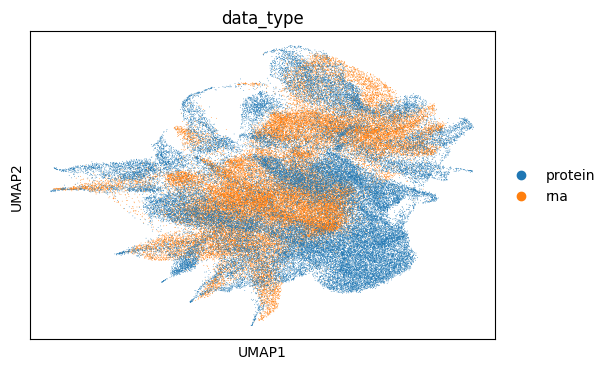

In [80]:
sc.pp.neighbors(cca_adata, n_neighbors=15)
sc.tl.umap(cca_adata)
sc.pl.umap(cca_adata, color='data_type')

In [83]:
# try to have some cell type annotation?
np.unique(labels_rna)

array(['Ambiguous', 'Benign Endometrial gland', 'Benign Stroma',
       'Carcinoma', 'Endothelial', 'Macrophage/DC', 'Myometrium',
       'Plasma/B', 'Sarcoma', 'T', 'Undif Carci'], dtype=object)

In [95]:
labels_pro = protein['phenoShort'].replace({'B': 'Plasma/B', 'Benign stroma vs perivascular smooth muscle': 'Benign Stroma', 'CD4': 'T',
                           'CD8': 'T', 'DC': 'Macrophage/DC', 'Fibroblast desmoplastic stroma population': 'Benign Stroma', 'HG sarcoma vs PD carcinoma': 'Ambiguous',
                           'M1': 'Macrophage/DC', 'M2': 'Macrophage/DC', 'Neutrophil': 'Other', 'Perivascular smooth muscle': 'Benign Stroma',
                           'Rhabdomyosarcoma': 'Sarcoma','Spindle carcinoma vs sarcoma': 'Ambiguous'}).astype(str).to_numpy()
np.unique(labels_pro)

array(['Ambiguous', 'Benign Stroma', 'Benign stroma', 'Carcinoma',
       'Endothelial', 'Macrophage/DC', 'Myometrium', 'Other', 'Plasma/B',
       'Sarcoma', 'T'], dtype=object)

In [96]:
cca_adata.obs['cell_type'] = list(np.concatenate((labels_rna[randix1],
                                                  labels_pro[full_matching[1]][randix2]), axis = 0))

/Users/bokaizhu/anaconda3/envs/maxfuse/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:391: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


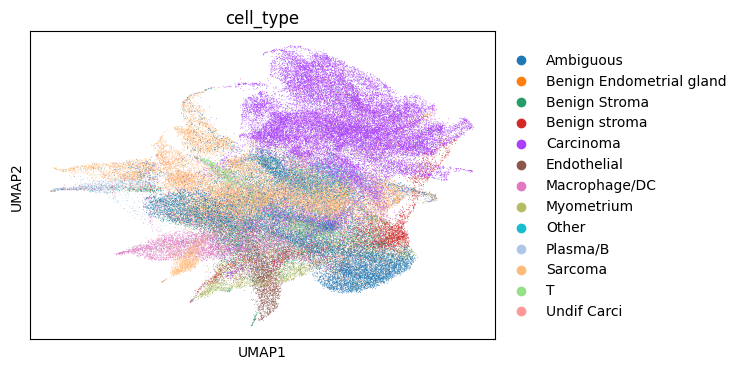

In [97]:
sc.pl.umap(cca_adata, color='cell_type')

In [100]:
## save out the embedding and matching table
pd.DataFrame(rna_cca).to_csv('../data/maxfuse1_rna.csv', index=False)
pd.DataFrame(protein_cca_sub).to_csv('../data/maxfuse1_pro.csv', index=False)

In [105]:
dd = {'id1':full_matching[0], 'id2':full_matching[1]}
pd.DataFrame(dd).to_csv('../data/maxfuse1_matchid.csv', index=False)

In [115]:
protein['phenoShort_swap'] = protein['phenoShort'].replace({'B': 'Plasma/B', 'Benign stroma vs perivascular smooth muscle': 'Benign Stroma', 'CD4': 'T',
                           'CD8': 'T', 'DC': 'Macrophage/DC', 'Fibroblast desmoplastic stroma population': 'Benign Stroma', 'HG sarcoma vs PD carcinoma': 'Ambiguous',
                           'M1': 'Macrophage/DC', 'M2': 'Macrophage/DC', 'Neutrophil': 'Other', 'Perivascular smooth muscle': 'Benign Stroma',
                           'Rhabdomyosarcoma': 'Sarcoma','Spindle carcinoma vs sarcoma': 'Ambiguous'}).astype(str)
protein.to_csv("../data/pro_maxinput_swap.csv", index=False)

KeyboardInterrupt: 